In [107]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

In [108]:
train = pd.read_csv('../data/train.csv')

In [109]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [110]:
train.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [111]:
train['SalePrice'].isna().sum()

np.int64(0)

<Axes: xlabel='SalePrice', ylabel='Count'>

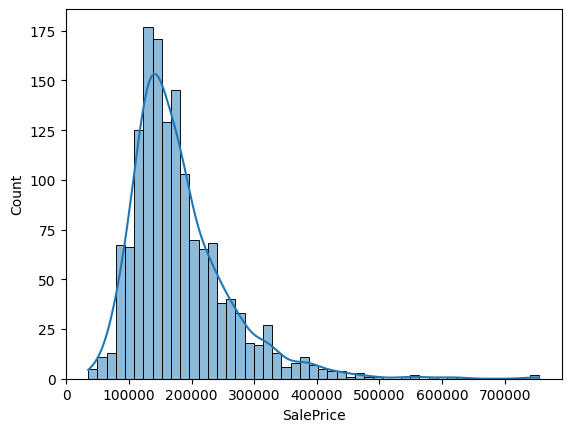

In [112]:
sns.histplot(train['SalePrice'], kde=True)

In [113]:
train['SalePrice'].skew()

np.float64(1.8828757597682129)

In [114]:
train['SalePrice_log'] = np.log(train['SalePrice'])

<Axes: xlabel='SalePrice_log', ylabel='Count'>

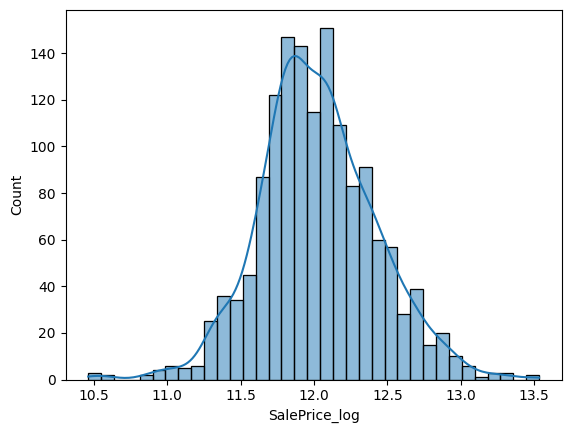

In [115]:
sns.histplot(train['SalePrice_log'], kde=True)

In [116]:
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

In [117]:
categoric_cols = train.select_dtypes(include=['object']).columns

C:\Users\mypci\AppData\Local\Temp\ipykernel_16360\4130061745.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoric_cols = train.select_dtypes(include=['object']).columns


In [118]:
corr = train[numeric_cols].corr()['SalePrice_log'].sort_values(ascending=False)

In [119]:
corr

SalePrice_log    1.000000
SalePrice        0.948374
OverallQual      0.817184
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
GarageYrBlt      0.541073
TotRmsAbvGrd     0.534422
Fireplaces       0.489449
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.355878
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209044
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057329
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorc

In [120]:
train['OverallQual'].value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

In [121]:
train['OverallQual'].isna().sum()

np.int64(0)

<Axes: xlabel='OverallQual', ylabel='Count'>

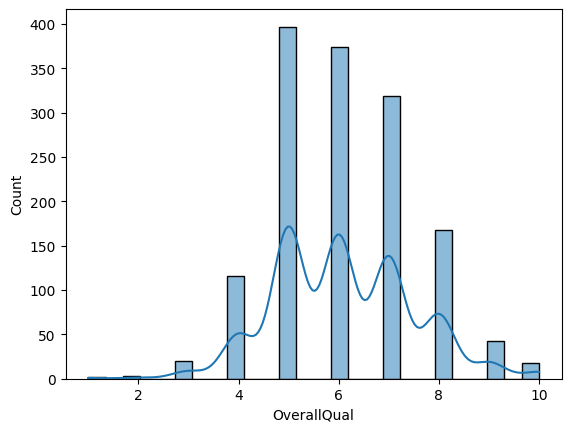

In [122]:
sns.histplot(train['OverallQual'], kde=True)

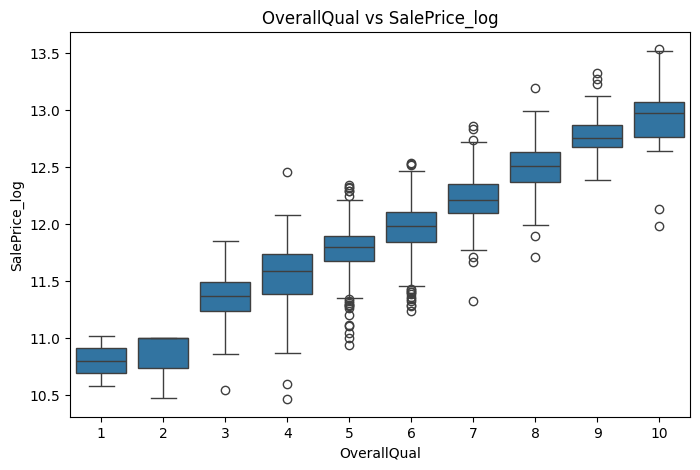

In [123]:
plt.figure(figsize=(8,5))
sns.boxplot(x='OverallQual', y='SalePrice_log', data=train)
plt.title('OverallQual vs SalePrice_log')
plt.show()

#### OverallQual ( highest correlation with SalePrice_log )
    - Almost nothing wrong. Normal Distribution. No Missing Values.

In [124]:
train['GrLivArea'].isna().sum()

np.int64(0)

In [125]:
train['GrLivArea']

0       1710
1       1262
2       1786
3       1717
4       2198
        ... 
1455    1647
1456    2073
1457    2340
1458    1078
1459    1256
Name: GrLivArea, Length: 1460, dtype: int64

<Axes: xlabel='GrLivArea', ylabel='SalePrice_log'>

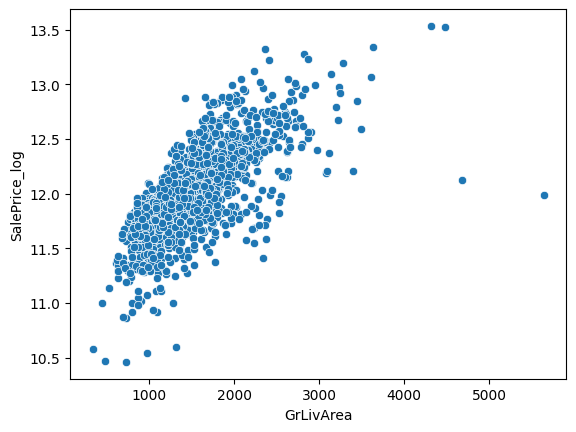

In [126]:
sns.scatterplot(x='GrLivArea', y='SalePrice_log', data=train)

In [127]:
train[train['GrLivArea'] > 4000]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,NaN,NaN,NaN,0,10,2007,New,Partial,184750,12.126759
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,1,2007,WD,Normal,755000,13.534473
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000,13.521139
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,Gd,NaN,NaN,0,1,2008,New,Partial,160000,11.982929


In [128]:
train = train.drop(train[train['Id'] == 1299].index)
train = train.drop(train[train['Id'] == 524].index)

<Axes: xlabel='GrLivArea', ylabel='SalePrice_log'>

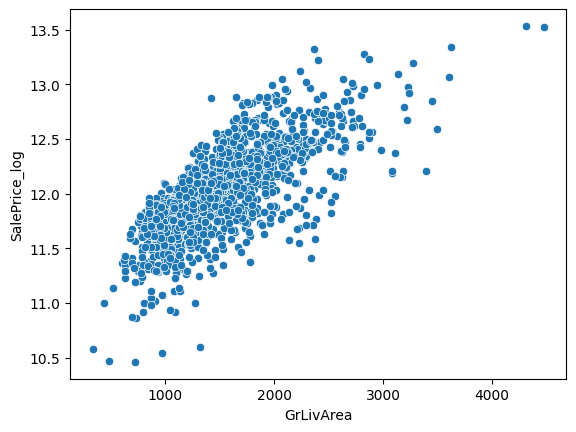

In [129]:
sns.scatterplot(x='GrLivArea', y='SalePrice_log', data=train)

In [130]:
train['GarageCars'].isna().sum()

np.int64(0)

In [131]:
train['GarageCars'].value_counts()
# Nothig wrong with GarageCars.

GarageCars
2    823
1    369
3    180
0     81
4      5
Name: count, dtype: int64

In [132]:
train['GarageArea'].isna().sum()

np.int64(0)

<Axes: xlabel='GarageArea', ylabel='SalePrice_log'>

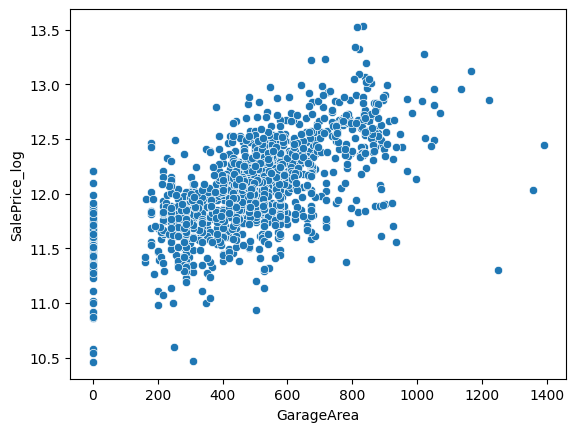

In [133]:
sns.scatterplot(x='GarageArea', y='SalePrice_log', data=train)

In [134]:
outliers = train[(train['GarageArea'] > 1200) & (train['SalePrice_log'] < 12.6)].index

In [135]:
train = train.drop(outliers)

<Axes: xlabel='GarageArea', ylabel='SalePrice_log'>

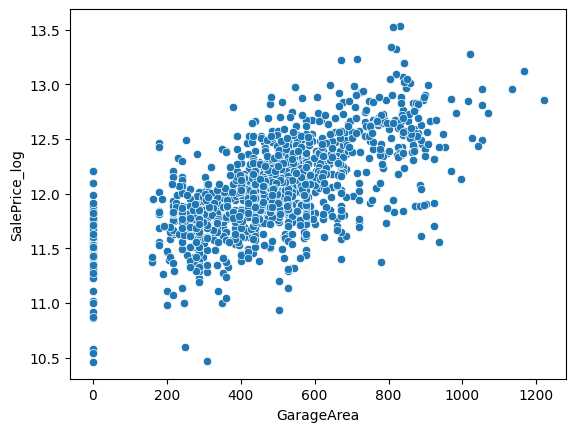

In [136]:
sns.scatterplot(x='GarageArea', y='SalePrice_log', data=train)

In [137]:
train['TotalBsmtSF'].isna().sum()

np.int64(0)

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice_log'>

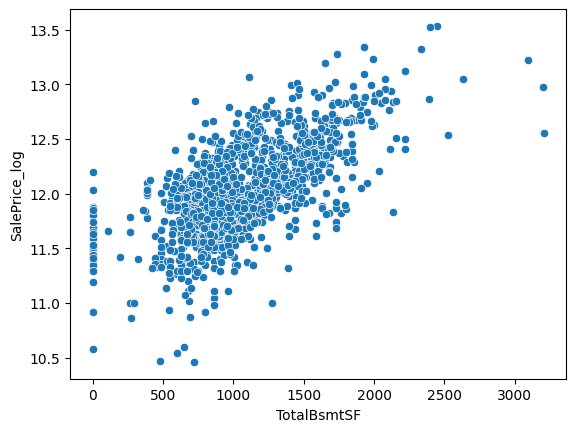

In [138]:
sns.scatterplot(x='TotalBsmtSF', y='SalePrice_log', data=train)

In [139]:
train['1stFlrSF'].isna().sum()

np.int64(0)

<Axes: xlabel='1stFlrSF', ylabel='SalePrice_log'>

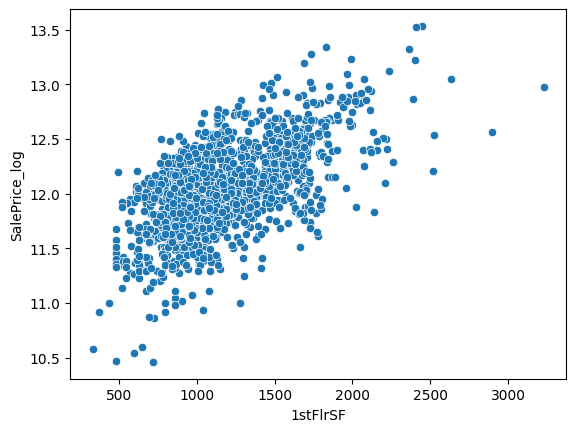

In [140]:
sns.scatterplot(x='1stFlrSF', y='SalePrice_log', data=train)

<Axes: xlabel='1stFlrSF', ylabel='SalePrice_log'>

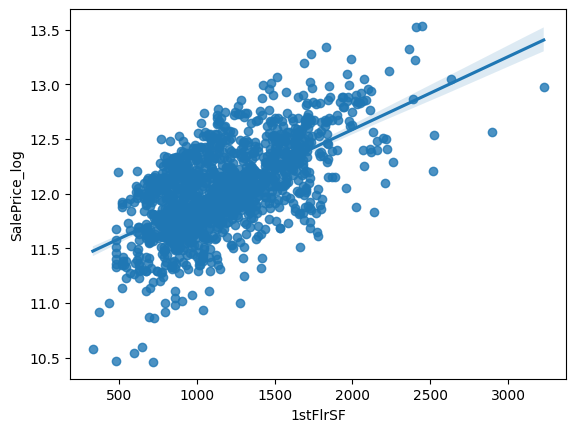

In [141]:
sns.regplot(x='1stFlrSF', y='SalePrice_log', data=train)

In [142]:
outliers = train[(train['1stFlrSF'] > 2700) & (train['SalePrice_log'] < 12.7)].index

In [143]:
train = train.drop(outliers)

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice_log'>

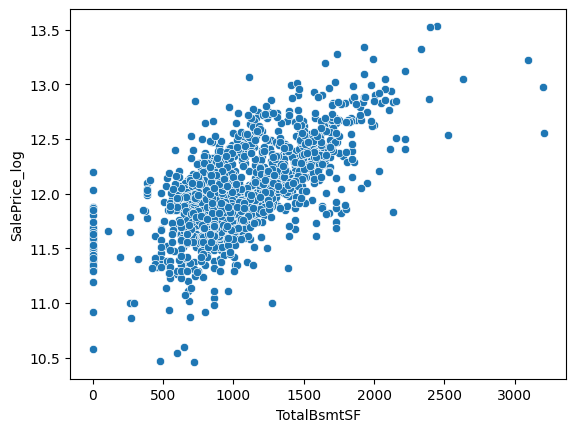

In [144]:
sns.scatterplot(x='TotalBsmtSF', y='SalePrice_log', data=train)

In [145]:
train['FullBath'].isna().sum()

np.int64(0)

<Axes: xlabel='FullBath', ylabel='SalePrice_log'>

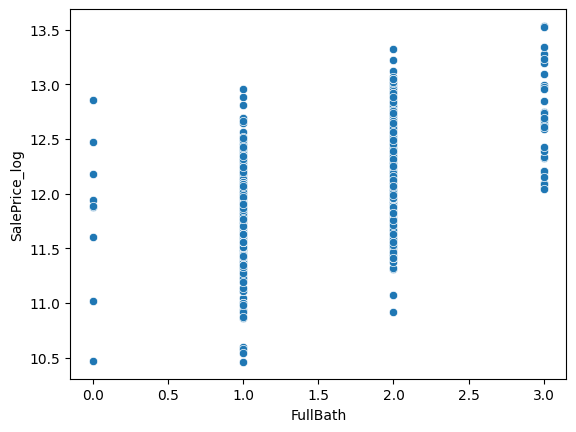

In [146]:
sns.scatterplot(x='FullBath', y='SalePrice_log', data=train)

<Axes: xlabel='FullBath', ylabel='SalePrice_log'>

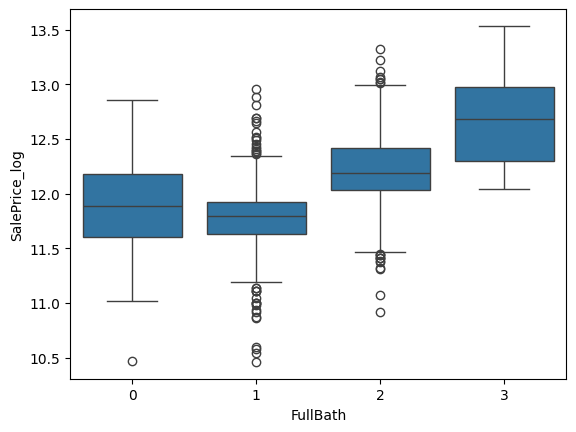

In [147]:
sns.boxplot(x='FullBath', y='SalePrice_log', data=train)

In [148]:
train[train['FullBath'] == 0][['SalePrice_log','HalfBath','BsmtFullBath','OverallQual','GrLivArea']]

,SalePrice_log,HalfBath,BsmtFullBath,OverallQual,GrLivArea
53,12.860999,1,2,9,1842
188,11.940393,2,2,5,1224
375,11.018629,1,1,1,904
597,12.176649,2,0,7,1402
634,11.877569,0,2,6,1056
916,10.471950,0,1,2,480
1163,11.598727,2,2,4,1258
1213,11.884489,0,1,4,960
1270,12.468437,1,2,7,1524


In [149]:
train['YearBuilt'].isna().sum()

np.int64(0)

<Axes: xlabel='YearBuilt', ylabel='SalePrice_log'>

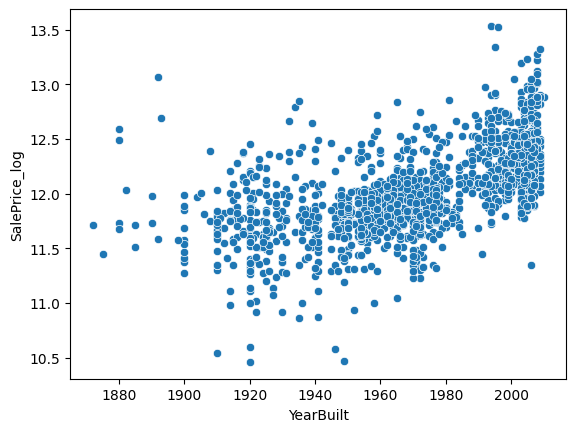

In [150]:
sns.scatterplot(x='YearBuilt', y='SalePrice_log', data=train)

In [151]:
train[train['YearBuilt'] < 1900][['SalePrice_log','OverallQual','GrLivArea']]

,SalePrice_log,OverallQual,GrLivArea
106,11.512925,4,1047
185,13.071070,10,3608
304,12.594731,7,3493
583,12.691580,10,2775
630,11.728037,5,1750
716,11.979799,7,2554
747,12.491173,7,2640
809,11.571194,5,2138
945,11.735269,5,1869
991,12.031719,8,1742


In [152]:
train['YearRemodAdd'].isna().sum()

np.int64(0)

<Axes: xlabel='YearRemodAdd', ylabel='SalePrice_log'>

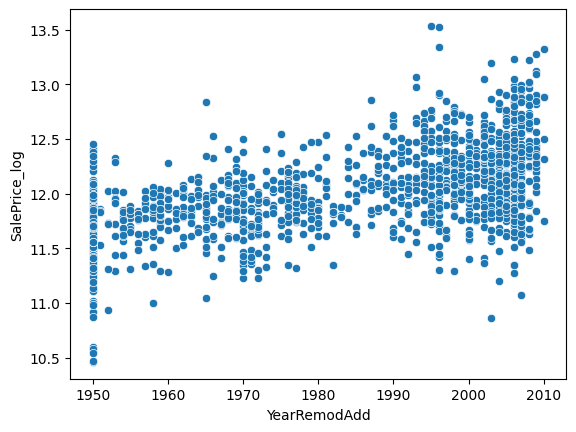

In [153]:
sns.scatterplot(x='YearRemodAdd', y='SalePrice_log', data=train)

In [154]:
# Create a binary flag for "was it remodeled?"
train['WasRemodeled'] = (train['YearRemodAdd'] != train['YearBuilt']).astype(int)

In [155]:
train['GarageYrBlt'].isna().sum()

np.int64(81)

In [156]:
train['GarageYrBlt']

0       2003.0
1       1976.0
2       2001.0
3       1998.0
4       2000.0
         ...  
1455    1999.0
1456    1978.0
1457    1941.0
1458    1950.0
1459    1965.0
Name: GarageYrBlt, Length: 1454, dtype: float64

In [157]:
train.shape

(1454, 83)

In [158]:
train['HasGarage'] = (train['GarageYrBlt'].notnull()).astype(int)

In [159]:
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['GarageYrBlt'].median())

<Axes: xlabel='GarageYrBlt', ylabel='SalePrice_log'>

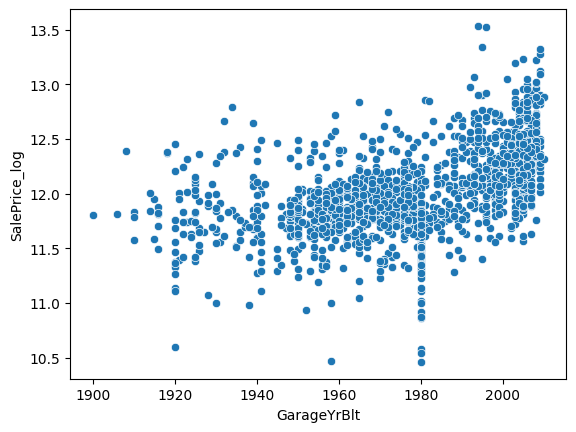

In [160]:
sns.scatterplot(x='GarageYrBlt', y='SalePrice_log', data=train)

In [161]:
train['GarageAge'] = train['YrSold'] - train['GarageYrBlt']

In [162]:
train['HouseAge'] = train['YrSold'] - train['YearBuilt']

<Axes: xlabel='TotRmsAbvGrd', ylabel='SalePrice_log'>

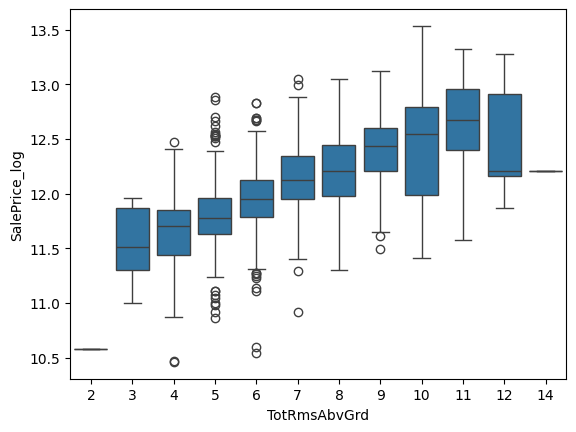

In [163]:
sns.boxplot(x='TotRmsAbvGrd', y='SalePrice_log', data=train)

In [164]:
train['TotRmsAbvGrd'].isna().sum()

np.int64(0)

In [165]:
train['Fireplaces'].isna().sum()

np.int64(0)

<Axes: xlabel='Fireplaces', ylabel='SalePrice_log'>

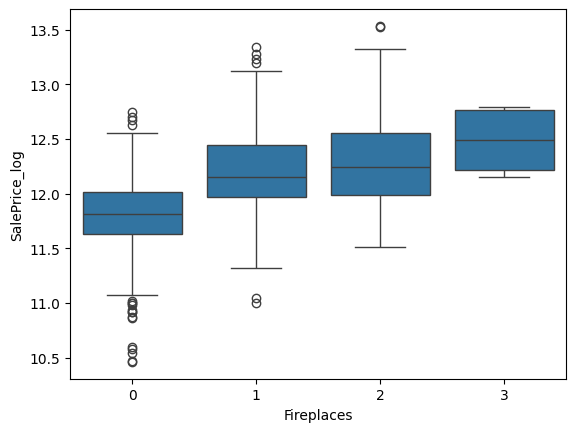

In [166]:
sns.boxplot(x='Fireplaces', y='SalePrice_log', data=train)

In [167]:
train['MasVnrType'].isna().sum()

np.int64(870)

In [168]:
train['MasVnrType'] = train['MasVnrType'].fillna('None')

In [169]:
train['MasVnrArea'].isna().sum()

np.int64(8)

In [170]:
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

<Axes: xlabel='MasVnrArea', ylabel='SalePrice_log'>

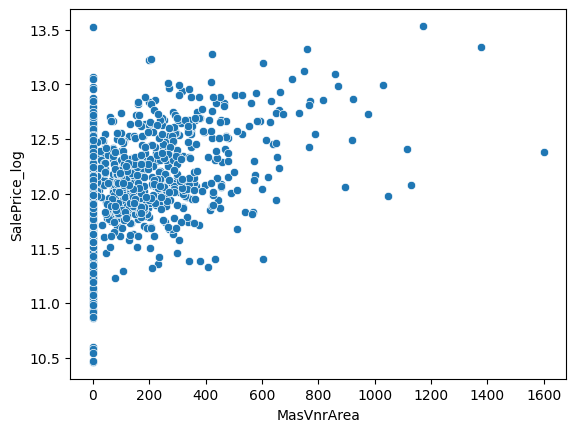

In [171]:
sns.scatterplot(x='MasVnrArea', y='SalePrice_log', data=train)

In [172]:
outliers = train[(train['MasVnrArea'] > 1000) & (train['SalePrice_log'] < 12.5)].index

In [173]:
corr = train[numeric_cols].corr()['SalePrice_log'].sort_values(ascending=False)

In [174]:
corr

SalePrice_log    1.000000
SalePrice        0.948332
OverallQual      0.821260
GrLivArea        0.724453
GarageCars       0.686445
GarageArea       0.669725
TotalBsmtSF      0.647281
1stFlrSF         0.621182
FullBath         0.595286
YearBuilt        0.586403
YearRemodAdd     0.565568
TotRmsAbvGrd     0.536824
GarageYrBlt      0.497578
Fireplaces       0.491194
MasVnrArea       0.430789
BsmtFinSF1       0.392029
LotFrontage      0.376553
WoodDeckSF       0.336308
OpenPorchSF      0.324710
2ndFlrSF         0.321254
HalfBath         0.314099
LotArea          0.261908
BsmtFullBath     0.236432
BsmtUnfSF        0.223209
BedroomAbvGr     0.209202
ScreenPorch      0.121632
PoolArea         0.074524
MoSold           0.058036
3SsnPorch        0.055082
BsmtFinSF2       0.002685
BsmtHalfBath    -0.005032
Id              -0.017265
MiscVal         -0.018624
YrSold          -0.037837
LowQualFinSF    -0.037982
OverallCond     -0.038681
MSSubClass      -0.073816
KitchenAbvGr    -0.147768
EnclosedPorc

In [175]:
numeric_cols = train.select_dtypes(include=np.number).columns
corr2 = train[numeric_cols].corr()['SalePrice_log'].sort_values(ascending=False)
print(corr2.head(15))

SalePrice_log    1.000000
SalePrice        0.948332
OverallQual      0.821260
GrLivArea        0.724453
GarageCars       0.686445
GarageArea       0.669725
TotalBsmtSF      0.647281
1stFlrSF         0.621182
FullBath         0.595286
YearBuilt        0.586403
YearRemodAdd     0.565568
TotRmsAbvGrd     0.536824
GarageYrBlt      0.497578
Fireplaces       0.491194
MasVnrArea       0.430789
Name: SalePrice_log, dtype: float64


- Categoricals

In [176]:
train['PoolQC'] = train['PoolQC'].fillna('None')

In [177]:
train['MiscFeature'] = train['MiscFeature'].fillna('None')

In [178]:
train['Alley'] = train['Alley'].fillna('None')
train['Fence'] = train['Fence'].fillna('None')
train['FireplaceQu'] = train['FireplaceQu'].fillna('None')

In [179]:
train.isna().sum().sort_values(ascending=False)

LotFrontage      257
GarageQual        81
GarageFinish      81
GarageType        81
GarageCond        81
                ... 
SalePrice_log      0
WasRemodeled       0
HasGarage          0
GarageAge          0
HouseAge           0
Length: 86, dtype: int64

In [180]:
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())

In [181]:
train['GarageFinish'] = train['GarageFinish'].fillna('None')
train['GarageCond'] = train['GarageCond'].fillna('None')
train['GarageQual'] = train['GarageQual'].fillna('None')
train['GarageType'] = train['GarageType'].fillna('None')

In [182]:
train['BsmtExposure'] = train['BsmtExposure'].fillna('None')
train['BsmtFinType2'] = train['BsmtFinType2'].fillna('None')
train['BsmtCond'] = train['BsmtCond'].fillna('None')
train['BsmtQual'] = train['BsmtQual'].fillna('None')
train['BsmtFinType1'] = train['BsmtFinType1'].fillna('None')

In [183]:
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

In [184]:
train.isna().sum().sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
SalePrice_log    0
WasRemodeled     0
HasGarage        0
GarageAge        0
HouseAge         0
Length: 86, dtype: int64

In [185]:
categorical_cols = train.select_dtypes(include='object').columns
print(categorical_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')


C:\Users\mypci\AppData\Local\Temp\ipykernel_16360\851566888.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include='object').columns


In [186]:
train['MSZoning'].isna().sum()

np.int64(0)

In [187]:
train['MSZoning'].value_counts()

MSZoning
RL         1146
RM          218
FV           65
RH           16
C (all)       9
Name: count, dtype: int64

In [188]:
# ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# MSZoning_encoded = ohe.fit_transform(train[['MSZoning']])

# MSZoning_df = pd.DataFrame(MSZoning_encoded, columns=ohe.get_feature_names_out(['MSZoning']))

# train = pd.concat([train, MSZoning_df], axis=1)
# train = train.drop('MSZoning', axis=1)

In [189]:
train['Street'].value_counts()

Street
Pave    1449
Grvl       5
Name: count, dtype: int64

In [190]:
train['Alley'].value_counts()

Alley
None    1363
Grvl      50
Pave      41
Name: count, dtype: int64

In [191]:
train['ExterCond'].value_counts()

ExterCond
TA    1277
Gd     145
Fa      28
Ex       3
Po       1
Name: count, dtype: int64

In [192]:
train['ExterQual'].value_counts()

ExterQual
TA    905
Gd    487
Ex     49
Fa     13
Name: count, dtype: int64

In [193]:
nominal_cols = ['MSZoning', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofMatl', 'Foundation', 'Electrical', 'SaleType', 'SaleCondition', 'SaleType', 'SaleCondition', 'Street','Neighborhood','LotShape','RoofStyle','Exterior1st','Exterior2nd','Heating','Functional','GarageType','GarageFinish','MasVnrType','MiscFeature','Alley','Fence']

nominal_cols = [col for col in nominal_cols if col in train.columns]

In [194]:
# First, we create a OneHotEncoder object.
# This just initializes the encoder — nothing happens yet.

# Then we use fit_transform on train[nominal_cols].
# Here we pass all nominal columns together as a matrix (not one by one).
# The encoder:
#   1) Looks at each column
#   2) Finds all unique categories in each column
#   3) Creates new binary columns (0/1) for every category
# The result is a big NumPy array containing all encoded columns combined.

# Next, we convert that NumPy array into a pandas DataFrame.
# We use:
#   columns = ohe.get_feature_names_out(nominal_cols)
# to generate proper column names like:
#   MSZoning_RL, Street_Pave, Neighborhood_NAmes, etc.
# instead of default numeric column names.

# index=train.index is very important.
# It keeps the row alignment exactly the same as the original train DataFrame.
# This ensures that when we concatenate, rows match correctly.

# Then we concatenate the original train DataFrame
# with the new encoded_df along axis=1 (column-wise).

# Finally, we drop the original nominal columns
# because they are now replaced by their encoded versions.

In [195]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(train[nominal_cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(nominal_cols), index=train.index)

train = pd.concat([train, encoded_df], axis=1)
train = train.drop(columns=nominal_cols)

In [196]:
ordinal_cols = ['HeatingQC', 'ExterQual','ExterCond','BsmtQual','BsmtCond','KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']

In [197]:
train['BsmtExposure'].value_counts()

BsmtExposure
No      951
Av      219
Gd      132
Mn      114
None     38
Name: count, dtype: int64

In [198]:
train['FireplaceQu'].value_counts()

FireplaceQu
None    689
Gd      376
TA      312
Fa       33
Ex       24
Po       20
Name: count, dtype: int64

In [199]:
qual_mapping = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

In [200]:
oe = OrdinalEncoder(categories=[['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']])

In [201]:
for col in ordinal_cols:
    train[[col]] = oe.fit_transform(train[[col]])

In [202]:
le = LabelEncoder()
train['PavedDrive'] = le.fit_transform(train['PavedDrive'])

In [203]:
train['CentralAir'] = le.fit_transform(train['CentralAir'])

In [204]:
exposure_qual = ['None', 'No', 'Mn', 'Av', 'Gd']

train['BsmtExposure'] = train['BsmtExposure'].replace({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}).astype(int)

fintype_qual = ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
train['BsmtFinType1'] = train['BsmtFinType1'].replace({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}).astype(int)
train['BsmtFinType2'] = train['BsmtFinType2'].replace({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}).astype(int)

In [205]:
# Select all non-numeric columns
non_numeric_cols = train.select_dtypes(exclude=['number']).columns
print(non_numeric_cols)

Index([], dtype='str')


In [206]:
non_numeric_cols = train.select_dtypes(exclude=['number']).columns


In [207]:
non_numeric_cols

Index([], dtype='str')

In [210]:
train.isna().sum().sum()

np.int64(0)

In [217]:
# Save preprocessed train to csv
train.to_csv('../data/train_preprocessed.csv', index=False)

Done with preprocessing. Now we will move to the modeling part. We will start with a simple Linear Regression model and then we will move to more complex models.

#### Modeling

In [211]:
model = LinearRegression()

X = train.drop(columns=['Id', 'SalePrice', 'SalePrice_log'])
y = train['SalePrice_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [212]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [213]:
y_pred = model.predict(X_test)

In [214]:
# Evaluate the model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 0.013992711633021487
R^2 Score: 0.9143270869125399
